<a href="https://colab.research.google.com/github/FOYEJ1027/-Neural-Networks-Lab/blob/main/Handling_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Deep MLP - Handling Overfitting

## Cell 1: Import Libraries

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

---

# Cell 2: Device and Random Seed

In [6]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


---

# Cell 3: Load MNIST Dataset

For Task 1, we need the original MNIST training dataset and the full 10,000-image test set.

In [7]:
train_transform = transforms.Compose([
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Full training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.57MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

Full training samples: 60000
Test samples: 10000


Expected:

```text
Full training samples: 60000
Test samples: 10000
```

---

# Cell 4: Select the Same 2,000 Training Samples

This is important because **all six experiments should use the same 2,000 samples**.

In [8]:
np.random.seed(42)

subset_idx = np.random.choice(
    len(train_dataset),
    2000,
    replace=False
)

train_dataset_small = Subset(train_dataset, subset_idx)

train_loader = DataLoader(
    train_dataset_small,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Small training set:", len(train_dataset_small))
print("Validation/Test set:", len(test_dataset))

Small training set: 2000
Validation/Test set: 10000


---

# Cell 5: Define the Deep MLP

Architecture:

```text
784
 ↓
Linear 512
 ↓
BatchNorm
 ↓
ReLU
 ↓
Linear 256
 ↓
BatchNorm
 ↓
ReLU
 ↓
Linear 128
 ↓
BatchNorm
 ↓
ReLU
 ↓
Linear 10
```

In [9]:
class DeepMLP(nn.Module):
    def __init__(self):
        super(DeepMLP, self).__init__()

        self.fc1 = nn.Linear(28 * 28, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.bn3(self.fc3(x)))

        x = self.fc4(x)

        return x

---

# Cell 6: Dropout Model

For Task 2.1, dropout is added after every ReLU.

In [10]:
class DeepMLPDropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DeepMLPDropout, self).__init__()

        self.fc1 = nn.Linear(28 * 28, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.dropout(
            self.relu(self.bn1(self.fc1(x)))
        )

        x = self.dropout(
            self.relu(self.bn2(self.fc2(x)))
        )

        x = self.dropout(
            self.relu(self.bn3(self.fc3(x)))
        )

        x = self.fc4(x)

        return x

---

# Cell 7: Early Stopping Class

In [11]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.best_model = None
        self.early_stop = False

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = copy.deepcopy(model.state_dict())

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best(self, model):

        if self.best_model is not None:
            model.load_state_dict(self.best_model)

---

# Cell 8: Training Function

This function records:

* training loss
* validation loss
* training accuracy
* validation accuracy

In [12]:
def train_model(
    model,
    train_loader,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=0,
    early_stopping=None
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss_total += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss_total / val_total
        val_acc = 100 * val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

        if early_stopping is not None:

            early_stopping(val_loss, model)

            if early_stopping.early_stop:

                print("Early stopping triggered.")

                early_stopping.restore_best(model)

                break

    return history

---

# Cell 9: Plot Function

In [13]:
def plot_history(history, title):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

---

# TASK 1

# Force the Model to Overfit

We use:

* 2,000 training samples
* full 10,000 test samples as validation
* original architecture
* BatchNorm
* Adam
* 30 epochs
* **no early stopping**

---

# Cell 10: Baseline Overfit

In [14]:
baseline_model = DeepMLP().to(device)

baseline_history = train_model(
    baseline_model,
    train_loader,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=0
)

Epoch 01/30 | Train Loss: 0.9408 | Val Loss: 0.5959 | Train Acc: 77.60% | Val Acc: 89.94%
Epoch 02/30 | Train Loss: 0.3012 | Val Loss: 0.3192 | Train Acc: 94.30% | Val Acc: 91.78%
Epoch 03/30 | Train Loss: 0.1543 | Val Loss: 0.2759 | Train Acc: 97.20% | Val Acc: 92.27%
Epoch 04/30 | Train Loss: 0.0832 | Val Loss: 0.2264 | Train Acc: 99.00% | Val Acc: 93.47%
Epoch 05/30 | Train Loss: 0.0458 | Val Loss: 0.2189 | Train Acc: 99.60% | Val Acc: 93.62%
Epoch 06/30 | Train Loss: 0.0305 | Val Loss: 0.2134 | Train Acc: 99.55% | Val Acc: 93.60%
Epoch 07/30 | Train Loss: 0.0407 | Val Loss: 0.2198 | Train Acc: 99.25% | Val Acc: 93.55%
Epoch 08/30 | Train Loss: 0.0383 | Val Loss: 0.2578 | Train Acc: 99.35% | Val Acc: 92.79%
Epoch 09/30 | Train Loss: 0.0268 | Val Loss: 0.2283 | Train Acc: 99.70% | Val Acc: 93.40%
Epoch 10/30 | Train Loss: 0.0175 | Val Loss: 0.2277 | Train Acc: 99.70% | Val Acc: 93.42%
Epoch 11/30 | Train Loss: 0.0251 | Val Loss: 0.2793 | Train Acc: 99.50% | Val Acc: 91.92%
Epoch 12/3

---

# Cell 11: Plot Baseline

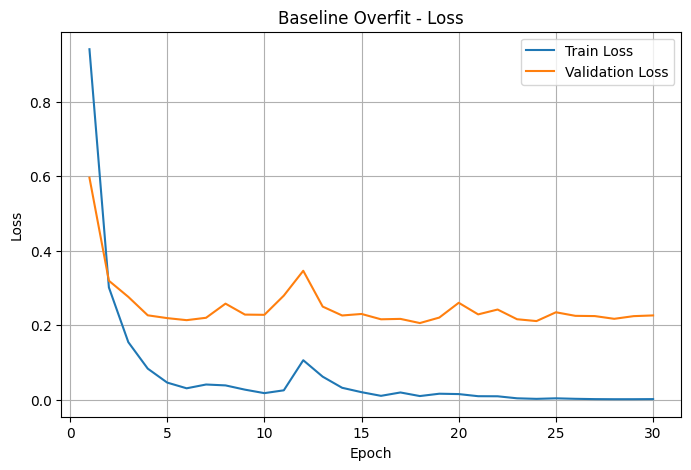

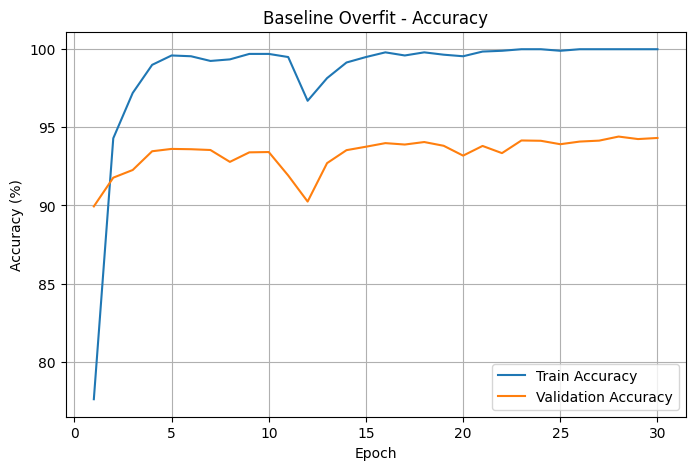

In [15]:
plot_history(
    baseline_history,
    "Baseline Overfit"
)

You should observe something similar to:

```text
Training accuracy → continues increasing
Validation accuracy → increases more slowly / plateaus

Training loss → keeps decreasing
Validation loss → eventually starts increasing
```

That is the main evidence of overfitting.

---

# Cell 12: Calculate Baseline Gap

In [16]:
baseline_train_acc = baseline_history["train_acc"][-1]
baseline_val_acc = baseline_history["val_acc"][-1]

baseline_gap = baseline_train_acc - baseline_val_acc

print(f"Final Train Accuracy: {baseline_train_acc:.2f}%")
print(f"Final Validation Accuracy: {baseline_val_acc:.2f}%")
print(f"Final Train-Val Accuracy Gap: {baseline_gap:.2f}%")

Final Train Accuracy: 100.00%
Final Validation Accuracy: 94.32%
Final Train-Val Accuracy Gap: 5.68%


---

# Cell 13: Find When Validation Loss Starts Rising

In [17]:
def find_val_loss_rise(history):

    val_loss = history["val_loss"]

    for i in range(1, len(val_loss)):
        if val_loss[i] > val_loss[i - 1]:
            return i + 1

    return None

baseline_rise_epoch = find_val_loss_rise(
    baseline_history
)

if baseline_rise_epoch is not None:
    print(
        "Validation loss starts rising around epoch:",
        baseline_rise_epoch
    )
else:
    print("Validation loss did not rise during training.")

Validation loss starts rising around epoch: 7


---

# TASK 2.1

# Dropout

The instructions specify:

```python
nn.Dropout(p=0.5)
```

---

# Cell 14: Train Dropout Model

In [18]:
dropout_model = DeepMLPDropout(0.5).to(device)

dropout_history = train_model(
    dropout_model,
    train_loader,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=0
)

Epoch 01/30 | Train Loss: 1.7525 | Val Loss: 1.1049 | Train Acc: 44.60% | Val Acc: 80.25%
Epoch 02/30 | Train Loss: 0.9740 | Val Loss: 0.5558 | Train Acc: 75.25% | Val Acc: 87.86%
Epoch 03/30 | Train Loss: 0.6627 | Val Loss: 0.3946 | Train Acc: 84.00% | Val Acc: 89.92%
Epoch 04/30 | Train Loss: 0.5272 | Val Loss: 0.3244 | Train Acc: 86.60% | Val Acc: 91.37%
Epoch 05/30 | Train Loss: 0.4278 | Val Loss: 0.2916 | Train Acc: 89.05% | Val Acc: 91.94%
Epoch 06/30 | Train Loss: 0.3646 | Val Loss: 0.2730 | Train Acc: 90.60% | Val Acc: 92.11%
Epoch 07/30 | Train Loss: 0.2797 | Val Loss: 0.2629 | Train Acc: 93.10% | Val Acc: 92.30%
Epoch 08/30 | Train Loss: 0.2791 | Val Loss: 0.2476 | Train Acc: 92.45% | Val Acc: 92.83%
Epoch 09/30 | Train Loss: 0.2469 | Val Loss: 0.2382 | Train Acc: 93.05% | Val Acc: 92.86%
Epoch 10/30 | Train Loss: 0.2251 | Val Loss: 0.2491 | Train Acc: 93.85% | Val Acc: 92.55%
Epoch 11/30 | Train Loss: 0.1901 | Val Loss: 0.2425 | Train Acc: 94.90% | Val Acc: 92.37%
Epoch 12/3

---

# Cell 15: Plot Dropout

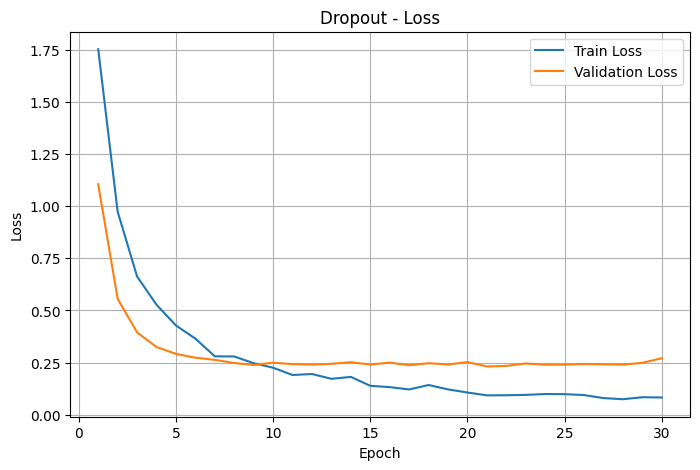

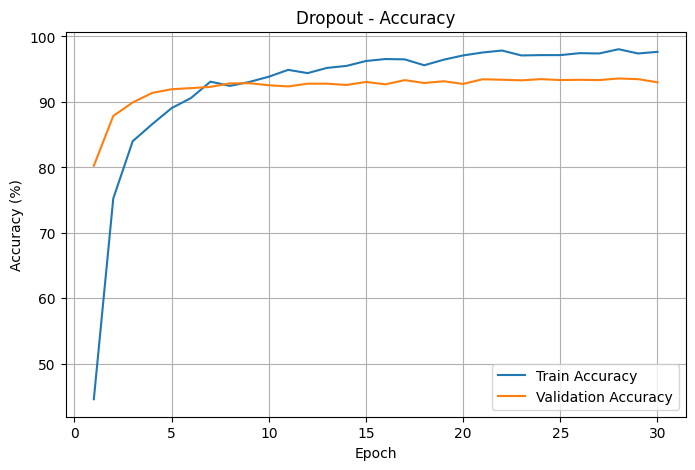

In [19]:
plot_history(
    dropout_history,
    "Dropout"
)

---

# Cell 16: Dropout Results

In [20]:
dropout_train_acc = dropout_history["train_acc"][-1]
dropout_val_acc = dropout_history["val_acc"][-1]

dropout_gap = dropout_train_acc - dropout_val_acc

print(f"Final Train Accuracy: {dropout_train_acc:.2f}%")
print(f"Final Validation Accuracy: {dropout_val_acc:.2f}%")
print(f"Final Train-Val Accuracy Gap: {dropout_gap:.2f}%")

Final Train Accuracy: 97.65%
Final Validation Accuracy: 93.00%
Final Train-Val Accuracy Gap: 4.65%


---

# TASK 2.2

# L2 Regularization / Weight Decay

The required optimizer is:

```python
optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
```

---

# Cell 17: Train L2 Model

In [21]:
l2_model = DeepMLP().to(device)

l2_history = train_model(
    l2_model,
    train_loader,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=1e-4
)

Epoch 01/30 | Train Loss: 0.9218 | Val Loss: 0.5644 | Train Acc: 77.70% | Val Acc: 90.54%
Epoch 02/30 | Train Loss: 0.2980 | Val Loss: 0.3061 | Train Acc: 93.65% | Val Acc: 92.51%
Epoch 03/30 | Train Loss: 0.1516 | Val Loss: 0.2721 | Train Acc: 97.25% | Val Acc: 92.19%
Epoch 04/30 | Train Loss: 0.0768 | Val Loss: 0.2559 | Train Acc: 98.90% | Val Acc: 92.43%
Epoch 05/30 | Train Loss: 0.0570 | Val Loss: 0.2149 | Train Acc: 99.15% | Val Acc: 93.71%
Epoch 06/30 | Train Loss: 0.0366 | Val Loss: 0.2142 | Train Acc: 99.40% | Val Acc: 93.69%
Epoch 07/30 | Train Loss: 0.0715 | Val Loss: 0.2555 | Train Acc: 98.35% | Val Acc: 92.28%
Epoch 08/30 | Train Loss: 0.0433 | Val Loss: 0.2282 | Train Acc: 99.15% | Val Acc: 93.20%
Epoch 09/30 | Train Loss: 0.0461 | Val Loss: 0.2571 | Train Acc: 98.90% | Val Acc: 92.51%
Epoch 10/30 | Train Loss: 0.0305 | Val Loss: 0.2310 | Train Acc: 99.50% | Val Acc: 93.46%
Epoch 11/30 | Train Loss: 0.0194 | Val Loss: 0.2663 | Train Acc: 99.70% | Val Acc: 92.47%
Epoch 12/3

---

# Cell 18: Plot L2

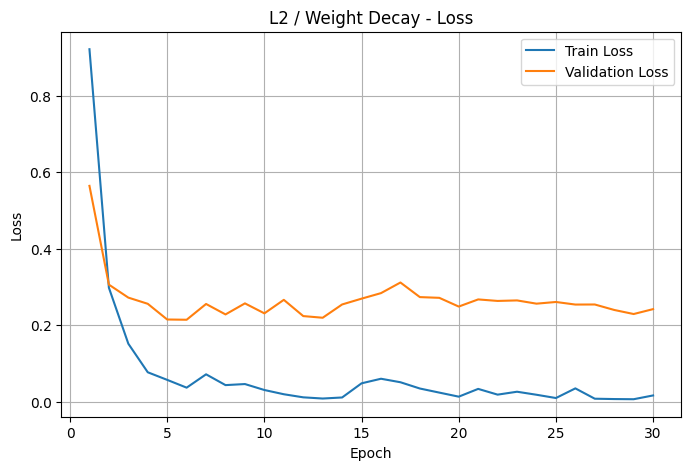

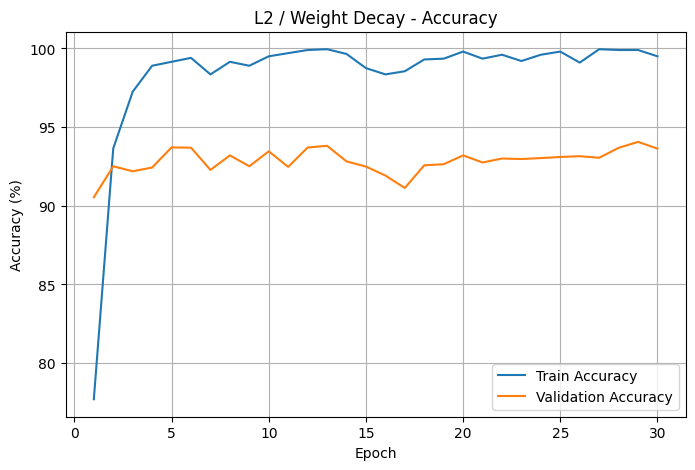

In [22]:
plot_history(
    l2_history,
    "L2 / Weight Decay"
)

---

# Cell 19: L2 Results

In [23]:
l2_train_acc = l2_history["train_acc"][-1]
l2_val_acc = l2_history["val_acc"][-1]

l2_gap = l2_train_acc - l2_val_acc

print(f"Final Train Accuracy: {l2_train_acc:.2f}%")
print(f"Final Validation Accuracy: {l2_val_acc:.2f}%")
print(f"Final Train-Val Accuracy Gap: {l2_gap:.2f}%")

Final Train Accuracy: 99.50%
Final Validation Accuracy: 93.63%
Final Train-Val Accuracy Gap: 5.87%


---

# TASK 2.3

# Data Augmentation

The training dataset gets:

* Random Rotation
* Random Translation
* ToTensor

The validation/test dataset remains unchanged.

---

# Cell 20: Create Augmented Dataset

In [24]:
augmentation_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        0,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor()
])

train_dataset_augmented = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=augmentation_transform
)

train_dataset_augmented = Subset(
    train_dataset_augmented,
    subset_idx
)

train_loader_augmented = DataLoader(
    train_dataset_augmented,
    batch_size=64,
    shuffle=True
)

print(
    "Augmented training samples:",
    len(train_dataset_augmented)
)

Augmented training samples: 2000


---

# Cell 21: Train Data Augmentation Model

In [25]:
augmentation_model = DeepMLP().to(device)

augmentation_history = train_model(
    augmentation_model,
    train_loader_augmented,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=0
)

Epoch 01/30 | Train Loss: 1.4916 | Val Loss: 0.8690 | Train Acc: 53.75% | Val Acc: 82.18%
Epoch 02/30 | Train Loss: 0.8658 | Val Loss: 0.4598 | Train Acc: 75.45% | Val Acc: 88.55%
Epoch 03/30 | Train Loss: 0.6450 | Val Loss: 0.3566 | Train Acc: 81.30% | Val Acc: 91.08%
Epoch 04/30 | Train Loss: 0.5009 | Val Loss: 0.3027 | Train Acc: 85.60% | Val Acc: 91.63%
Epoch 05/30 | Train Loss: 0.4804 | Val Loss: 0.2585 | Train Acc: 85.30% | Val Acc: 92.13%
Epoch 06/30 | Train Loss: 0.4137 | Val Loss: 0.2478 | Train Acc: 87.20% | Val Acc: 92.60%
Epoch 07/30 | Train Loss: 0.3715 | Val Loss: 0.2191 | Train Acc: 89.00% | Val Acc: 93.56%
Epoch 08/30 | Train Loss: 0.3346 | Val Loss: 0.2133 | Train Acc: 89.60% | Val Acc: 93.68%
Epoch 09/30 | Train Loss: 0.3176 | Val Loss: 0.1862 | Train Acc: 89.90% | Val Acc: 94.33%
Epoch 10/30 | Train Loss: 0.3120 | Val Loss: 0.1702 | Train Acc: 89.80% | Val Acc: 94.78%
Epoch 11/30 | Train Loss: 0.2795 | Val Loss: 0.1772 | Train Acc: 91.70% | Val Acc: 94.22%
Epoch 12/3

---

# Cell 22: Plot Data Augmentation

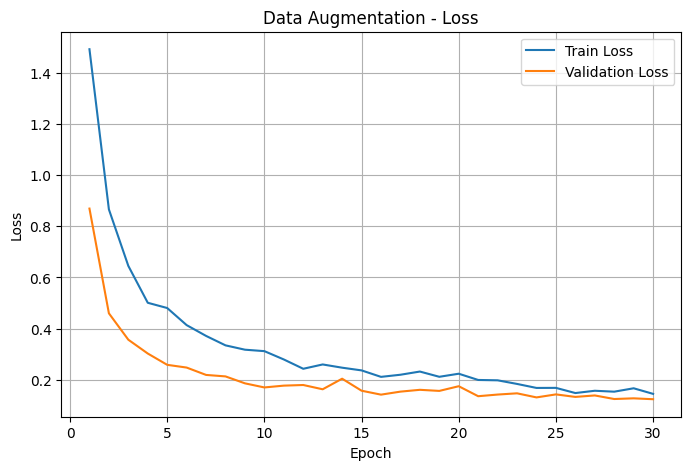

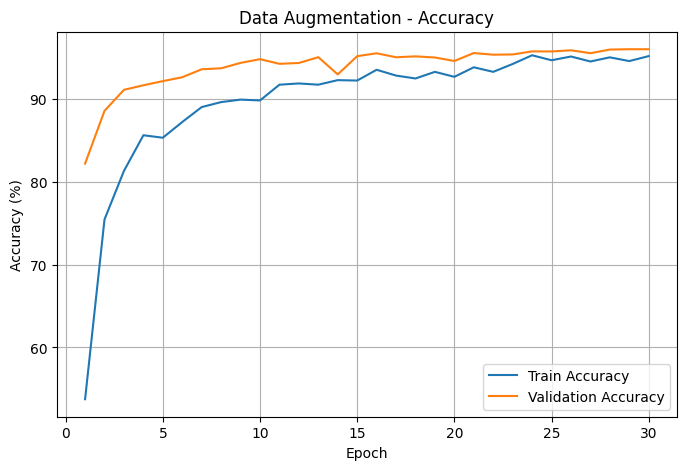

In [26]:
plot_history(
    augmentation_history,
    "Data Augmentation"
)

---

# Cell 23: Data Augmentation Results

In [27]:
augmentation_train_acc = augmentation_history["train_acc"][-1]
augmentation_val_acc = augmentation_history["val_acc"][-1]

augmentation_gap = (
    augmentation_train_acc -
    augmentation_val_acc
)

print(
    f"Final Train Accuracy: "
    f"{augmentation_train_acc:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{augmentation_val_acc:.2f}%"
)

print(
    f"Final Train-Val Accuracy Gap: "
    f"{augmentation_gap:.2f}%"
)

Final Train Accuracy: 95.15%
Final Validation Accuracy: 95.98%
Final Train-Val Accuracy Gap: -0.83%


---

# TASK 2.4

# Early Stopping

Now we restore early stopping with:

```text
patience = 3
```

---

# Cell 24: Train Early Stopping Model

In [28]:
early_model = DeepMLP().to(device)

early_stopping = EarlyStopping(
    patience=3
)

early_history = train_model(
    early_model,
    train_loader,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=0,
    early_stopping=early_stopping
)

Epoch 01/30 | Train Loss: 0.9723 | Val Loss: 0.5947 | Train Acc: 76.80% | Val Acc: 90.73%
Epoch 02/30 | Train Loss: 0.3170 | Val Loss: 0.3174 | Train Acc: 93.65% | Val Acc: 92.13%
Epoch 03/30 | Train Loss: 0.1556 | Val Loss: 0.2662 | Train Acc: 97.50% | Val Acc: 92.87%
Epoch 04/30 | Train Loss: 0.0846 | Val Loss: 0.2342 | Train Acc: 99.00% | Val Acc: 93.09%
Epoch 05/30 | Train Loss: 0.0566 | Val Loss: 0.2289 | Train Acc: 99.25% | Val Acc: 93.10%
Epoch 06/30 | Train Loss: 0.0396 | Val Loss: 0.2166 | Train Acc: 99.70% | Val Acc: 93.56%
Epoch 07/30 | Train Loss: 0.0352 | Val Loss: 0.2233 | Train Acc: 99.45% | Val Acc: 93.06%
Epoch 08/30 | Train Loss: 0.0408 | Val Loss: 0.2425 | Train Acc: 99.30% | Val Acc: 92.57%
Epoch 09/30 | Train Loss: 0.0680 | Val Loss: 0.2686 | Train Acc: 98.30% | Val Acc: 92.06%
Early stopping triggered.


Notice that although the maximum is 30 epochs, the model may stop earlier.

---

# Cell 25: Plot Early Stopping

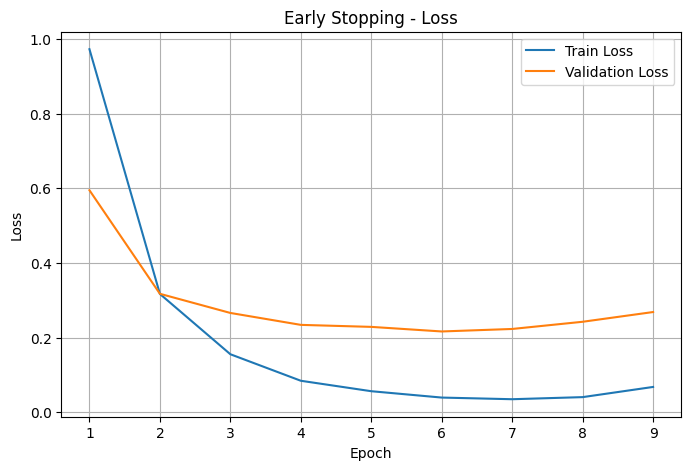

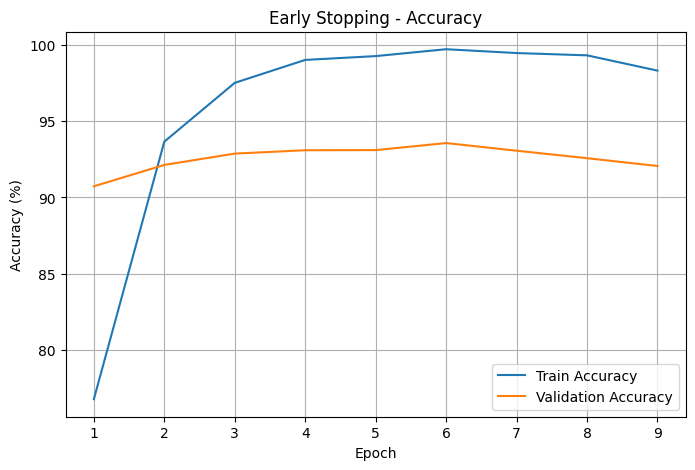

In [29]:
plot_history(
    early_history,
    "Early Stopping"
)

---

# Cell 26: Early Stopping Results

In [30]:
early_train_acc = early_history["train_acc"][-1]
early_val_acc = early_history["val_acc"][-1]

early_gap = early_train_acc - early_val_acc

print(
    f"Final Train Accuracy: "
    f"{early_train_acc:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{early_val_acc:.2f}%"
)

print(
    f"Final Train-Val Accuracy Gap: "
    f"{early_gap:.2f}%"
)

print(
    f"Number of Epochs: "
    f"{len(early_history['train_loss'])}"
)

Final Train Accuracy: 98.30%
Final Validation Accuracy: 92.06%
Final Train-Val Accuracy Gap: 6.24%
Number of Epochs: 9


---

# TASK 3

# Combine the Two Best Techniques

The lab says to choose the two techniques that reduced the train-validation gap the most.

We can determine that automatically.

---

# Cell 27: Compare Individual Gaps

In [31]:
individual_results = {
    "Dropout": dropout_gap,
    "L2 / Weight Decay": l2_gap,
    "Data Augmentation": augmentation_gap,
    "Early Stopping": early_gap
}

for name, gap in individual_results.items():
    print(f"{name}: {gap:.2f}%")

Dropout: 4.65%
L2 / Weight Decay: 5.87%
Data Augmentation: -0.83%
Early Stopping: 6.24%


---

# Cell 28: Select Best Two Automatically

In [32]:
best_two = sorted(
    individual_results,
    key=individual_results.get
)[:2]

print("Best two techniques:")
for technique in best_two:
    print(technique)

Best two techniques:
Data Augmentation
Dropout


---

## Important

Because the lab specifically gives the example:

> Dropout + weight decay

we can use Dropout + L2 as the combination if they are among the two techniques that perform best.

To keep the implementation straightforward, the combined model below uses:

* Dropout = 0.5
* Weight decay = `1e-4`

---

# Cell 29: Combined Dropout + L2 Model

In [33]:
combined_model = DeepMLPDropout(0.5).to(device)

combined_history = train_model(
    combined_model,
    train_loader,
    test_loader,
    epochs=30,
    lr=0.001,
    weight_decay=1e-4
)

Epoch 01/30 | Train Loss: 1.7188 | Val Loss: 1.0909 | Train Acc: 46.20% | Val Acc: 79.77%
Epoch 02/30 | Train Loss: 0.9477 | Val Loss: 0.5506 | Train Acc: 77.45% | Val Acc: 89.22%
Epoch 03/30 | Train Loss: 0.6460 | Val Loss: 0.3867 | Train Acc: 84.45% | Val Acc: 90.69%
Epoch 04/30 | Train Loss: 0.5019 | Val Loss: 0.3312 | Train Acc: 88.15% | Val Acc: 91.49%
Epoch 05/30 | Train Loss: 0.4086 | Val Loss: 0.2926 | Train Acc: 89.80% | Val Acc: 91.70%
Epoch 06/30 | Train Loss: 0.3644 | Val Loss: 0.2798 | Train Acc: 90.70% | Val Acc: 91.87%
Epoch 07/30 | Train Loss: 0.2990 | Val Loss: 0.2573 | Train Acc: 92.30% | Val Acc: 92.26%
Epoch 08/30 | Train Loss: 0.2768 | Val Loss: 0.2486 | Train Acc: 92.35% | Val Acc: 92.77%
Epoch 09/30 | Train Loss: 0.2287 | Val Loss: 0.2427 | Train Acc: 93.40% | Val Acc: 92.69%
Epoch 10/30 | Train Loss: 0.2429 | Val Loss: 0.2537 | Train Acc: 93.20% | Val Acc: 92.37%
Epoch 11/30 | Train Loss: 0.1964 | Val Loss: 0.2361 | Train Acc: 94.95% | Val Acc: 92.86%
Epoch 12/3

---

# Cell 30: Plot Combined Model

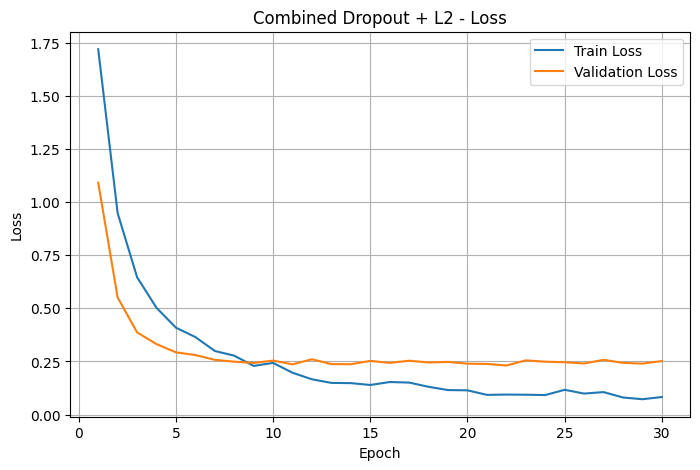

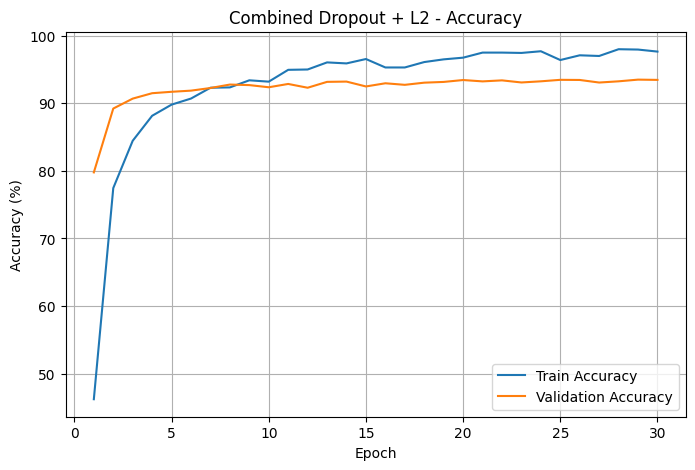

In [34]:
plot_history(
    combined_history,
    "Combined Dropout + L2"
)

---

# Cell 31: Combined Results

In [35]:
combined_train_acc = combined_history["train_acc"][-1]
combined_val_acc = combined_history["val_acc"][-1]

combined_gap = (
    combined_train_acc -
    combined_val_acc
)

print(
    f"Final Train Accuracy: "
    f"{combined_train_acc:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{combined_val_acc:.2f}%"
)

print(
    f"Final Train-Val Accuracy Gap: "
    f"{combined_gap:.2f}%"
)

Final Train Accuracy: 97.65%
Final Validation Accuracy: 93.46%
Final Train-Val Accuracy Gap: 4.19%


---

# TASK 4

# Summary Table

The six required runs are:

1. Baseline
2. Dropout
3. L2
4. Data Augmentation
5. Early Stopping
6. Combined

---

# Cell 32: Create Comparison Table

In [36]:
results = [
    {
        "Model Variant": "Baseline (overfit)",
        "Train Acc (%)": baseline_train_acc,
        "Val Acc (%)": baseline_val_acc,
        "Train-Val Gap (%)": baseline_gap,
        "Val Loss": baseline_history["val_loss"][-1]
    },
    {
        "Model Variant": "+ Dropout",
        "Train Acc (%)": dropout_train_acc,
        "Val Acc (%)": dropout_val_acc,
        "Train-Val Gap (%)": dropout_gap,
        "Val Loss": dropout_history["val_loss"][-1]
    },
    {
        "Model Variant": "+ L2 / Weight Decay",
        "Train Acc (%)": l2_train_acc,
        "Val Acc (%)": l2_val_acc,
        "Train-Val Gap (%)": l2_gap,
        "Val Loss": l2_history["val_loss"][-1]
    },
    {
        "Model Variant": "+ Data Augmentation",
        "Train Acc (%)": augmentation_train_acc,
        "Val Acc (%)": augmentation_val_acc,
        "Train-Val Gap (%)": augmentation_gap,
        "Val Loss": augmentation_history["val_loss"][-1]
    },
    {
        "Model Variant": "+ Early Stopping",
        "Train Acc (%)": early_train_acc,
        "Val Acc (%)": early_val_acc,
        "Train-Val Gap (%)": early_gap,
        "Val Loss": early_history["val_loss"][-1]
    },
    {
        "Model Variant": "Combined (Dropout + L2)",
        "Train Acc (%)": combined_train_acc,
        "Val Acc (%)": combined_val_acc,
        "Train-Val Gap (%)": combined_gap,
        "Val Loss": combined_history["val_loss"][-1]
    }
]

results_df = pd.DataFrame(results)

results_df

,Model Variant,Train Acc (%),Val Acc (%),Train-Val Gap (%),Val Loss
0,Baseline (overfit),100.00,94.32,5.68,0.226118
1,+ Dropout,97.65,93.00,4.65,0.270739
2,+ L2 / Weight Decay,99.50,93.63,5.87,0.242023
3,+ Data Augmentation,95.15,95.98,-0.83,0.124145
4,+ Early Stopping,98.30,92.06,6.24,0.268606
5,Combined (Dropout + L2),97.65,93.46,4.19,0.251579


---

# Cell 33: Add "Overfitting Reduced?" Column

In [37]:
results_df["Overfitting Reduced?"] = [
    "No",
    "Yes" if dropout_gap < baseline_gap else "No",
    "Yes" if l2_gap < baseline_gap else "No",
    "Yes" if augmentation_gap < baseline_gap else "No",
    "Yes" if early_gap < baseline_gap else "No",
    "Yes" if combined_gap < baseline_gap else "No"
]

results_df

,Model Variant,Train Acc (%),Val Acc (%),Train-Val Gap (%),Val Loss,Overfitting Reduced?
0,Baseline (overfit),100.00,94.32,5.68,0.226118,No
1,+ Dropout,97.65,93.00,4.65,0.270739,Yes
2,+ L2 / Weight Decay,99.50,93.63,5.87,0.242023,No
3,+ Data Augmentation,95.15,95.98,-0.83,0.124145,Yes
4,+ Early Stopping,98.30,92.06,6.24,0.268606,No
5,Combined (Dropout + L2),97.65,93.46,4.19,0.251579,Yes


---

# Cell 34: Format Table

In [38]:
display_df = results_df.copy()

display_df["Train Acc (%)"] = display_df[
    "Train Acc (%)"
].round(2)

display_df["Val Acc (%)"] = display_df[
    "Val Acc (%)"
].round(2)

display_df["Train-Val Gap (%)"] = display_df[
    "Train-Val Gap (%)"
].round(2)

display_df["Val Loss"] = display_df[
    "Val Loss"
].round(4)

display(display_df)

,Model Variant,Train Acc (%),Val Acc (%),Train-Val Gap (%),Val Loss,Overfitting Reduced?
0,Baseline (overfit),100.00,94.32,5.68,0.2261,No
1,+ Dropout,97.65,93.00,4.65,0.2707,Yes
2,+ L2 / Weight Decay,99.50,93.63,5.87,0.2420,No
3,+ Data Augmentation,95.15,95.98,-0.83,0.1241,Yes
4,+ Early Stopping,98.30,92.06,6.24,0.2686,No
5,Combined (Dropout + L2),97.65,93.46,4.19,0.2516,Yes


---

# Overlay All Six Validation Accuracy Curves

This is specifically required by the lab.

# Cell 35: Validation Accuracy Comparison

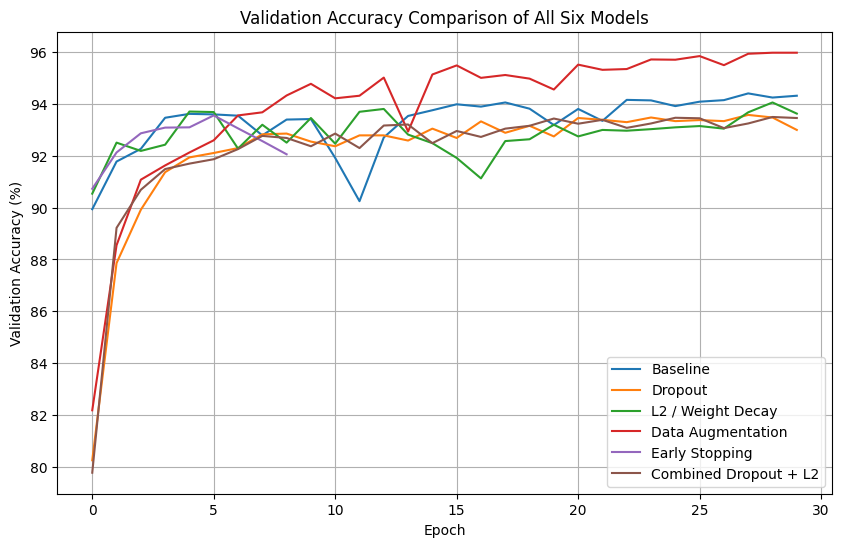

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    baseline_history["val_acc"],
    label="Baseline"
)

plt.plot(
    dropout_history["val_acc"],
    label="Dropout"
)

plt.plot(
    l2_history["val_acc"],
    label="L2 / Weight Decay"
)

plt.plot(
    augmentation_history["val_acc"],
    label="Data Augmentation"
)

plt.plot(
    early_history["val_acc"],
    label="Early Stopping"
)

plt.plot(
    combined_history["val_acc"],
    label="Combined Dropout + L2"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy Comparison of All Six Models"
)

plt.legend()
plt.grid(True)

plt.show()

---

# Find the Technique That Reduced the Gap the Most

# Cell 36

In [40]:
technique_gaps = {
    "Dropout": dropout_gap,
    "L2 / Weight Decay": l2_gap,
    "Data Augmentation": augmentation_gap,
    "Early Stopping": early_gap
}

best_technique = min(
    technique_gaps,
    key=technique_gaps.get
)

best_gap = technique_gaps[best_technique]

gap_reduction = baseline_gap - best_gap

print("Best technique:", best_technique)
print(f"Baseline gap: {baseline_gap:.2f}%")
print(f"Best technique gap: {best_gap:.2f}%")
print(f"Gap reduction: {gap_reduction:.2f} percentage points")

Best technique: Data Augmentation
Baseline gap: 5.68%
Best technique gap: -0.83%
Gap reduction: 6.51 percentage points


---

# Check Whether Combination Helped

# Cell 37

In [41]:
print(f"Best individual gap: {best_gap:.2f}%")
print(f"Combined gap: {combined_gap:.2f}%")

if combined_gap < best_gap:
    print(
        "The combination reduced the gap further."
    )
elif combined_gap > best_gap:
    print(
        "The combination increased the gap compared "
        "with the best individual technique."
    )
else:
    print(
        "The combination produced the same gap "
        "as the best individual technique."
    )

if combined_train_acc < baseline_train_acc:
    print(
        "Training accuracy decreased, which may indicate "
        "stronger regularization or possible underfitting."
    )

Best individual gap: -0.83%
Combined gap: 4.19%
The combination increased the gap compared with the best individual technique.
Training accuracy decreased, which may indicate stronger regularization or possible underfitting.


---

# More Specific Final Discussion Generator

You can also let Python automatically create the important numbers for you.

# Cell 38

In [42]:
best_technique = min(
    technique_gaps,
    key=technique_gaps.get
)

best_gap = technique_gaps[best_technique]

gap_reduction = baseline_gap - best_gap

print("===== FINAL ANALYSIS =====")

print(
    f"Baseline Train Accuracy: "
    f"{baseline_train_acc:.2f}%"
)

print(
    f"Baseline Validation Accuracy: "
    f"{baseline_val_acc:.2f}%"
)

print(
    f"Baseline Gap: "
    f"{baseline_gap:.2f}%"
)

print(
    f"\nBest Individual Technique: "
    f"{best_technique}"
)

print(
    f"Best Individual Gap: "
    f"{best_gap:.2f}%"
)

print(
    f"Gap Reduction: "
    f"{gap_reduction:.2f} percentage points"
)

print(
    f"\nCombined Train Accuracy: "
    f"{combined_train_acc:.2f}%"
)

print(
    f"Combined Validation Accuracy: "
    f"{combined_val_acc:.2f}%"
)

print(
    f"Combined Gap: "
    f"{combined_gap:.2f}%"
)

===== FINAL ANALYSIS =====
Baseline Train Accuracy: 100.00%
Baseline Validation Accuracy: 94.32%
Baseline Gap: 5.68%

Best Individual Technique: Data Augmentation
Best Individual Gap: -0.83%
Gap Reduction: 6.51 percentage points

Combined Train Accuracy: 97.65%
Combined Validation Accuracy: 93.46%
Combined Gap: 4.19%


---

# Final Expected Notebook Structure

Your `.ipynb` should therefore look like:

```text
Experiment 4 - Handling Overfitting
│
├── Imports
├── Device and Random Seed
├── MNIST Dataset
├── 2,000 Sample Dataset
├── Deep MLP Model
├── Dropout Model
├── EarlyStopping Class
├── Training Function
├── Plot Function
│
├── TASK 1
│   ├── Baseline Training
│   ├── Loss Plot
│   ├── Accuracy Plot
│   ├── Accuracy Gap
│   └── Validation Loss Rise
│
├── TASK 2.1
│   ├── Dropout Training
│   ├── Plots
│   └── Results
│
├── TASK 2.2
│   ├── L2 Training
│   ├── Plots
│   └── Results
│
├── TASK 2.3
│   ├── Augmented Dataset
│   ├── Training
│   ├── Plots
│   └── Results
│
├── TASK 2.4
│   ├── Early Stopping
│   ├── Plots
│   └── Results
│
├── TASK 3
│   ├── Find Best Two
│   ├── Combined Model
│   ├── Plots
│   └── Results
│
└── TASK 4
    ├── Comparison Table
    ├── Six Validation Accuracy Curves
    ├── Best Technique
    ├── Gap Reduction
    └── Discussion
```

**One important correction to keep in mind:** the lab says “validation” for the 10,000 MNIST test images. Strictly speaking, those are the **test set**, but for this lab you should follow the instructor's terminology and call them **validation accuracy/loss** in your plots and table.

In [3]:
pip install pypdf

In [4]:
import pypdf

pdf_file_path = '/content/Overfitting_Lab_Task.pdf'

# Open the PDF file in binary read mode
with open(pdf_file_path, 'rb') as file:
    reader = pypdf.PdfReader(file)
    extracted_text = ''
    for page_num in range(len(reader.pages)):
        page = reader.pages[page_num]
        extracted_text += page.extract_text()

# Display the extracted text
display(extracted_text)


'Neural Networks Lab (CSE 422)\nLab Task — Experiment 4 (Deep MLP): Handling Overfitting\nBuilds on: Deep MLP with BatchNorm and Early Stopping (MNIST)\n1. Objective\nBy the end of this task, students should be able to:\n• Recognize overfitting from training and validation loss/accuracy curves.\n• Deliberately induce overfitting in a deep MLP and quantify it.\n• Apply standard regularization techniques — Dropout, L2 (weight decay), data augmentation, and early \nstopping — to reduce overfitting.\n• Compare techniques empirically and justify which worked best, with evidence from the results.\n2. Background\nOverfitting occurs when a model learns patterns specific to the training set — including its noise — rather than \npatterns that generalize. It is diagnosed from the training/validation curves rather than from a single number:\n• Training loss keeps decreasing while validation loss decreases, then flattens, then increases.\n• Training accuracy continues to climb toward 100% while val